# Product Framing — Identifying Credit-Building Potential by Segment

This notebook ties together the segmentation and modeling work to answer a concrete product question: **which borrowers are most likely to successfully build credit, and what should a fintech do differently for each segment?**

This is the "so what" of the entire project — translating analytical findings into actionable product recommendations in the way a data scientist at a consumer fintech would present to a product or growth team.

**Key questions explored:**
- Which cluster has the highest credit-building potential?
- Which segment is most underserved by traditional credit products?
- How should product design, onboarding, or credit limits differ by segment?

**Approach:**
- Overlay delinquency risk scores onto customer segments
- Profile each segment by risk level and financial behavior
- Map segments to product responses
- Summarize findings as a stakeholder-ready narrative

**Input:** `data/clustered.csv` + model outputs from `03_modeling.ipynb`

## 1. Load modeled.csv

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("data/modeled.csv")

In [6]:
print(df.shape)
print(df.columns.to_list())

(150000, 26)
['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'MonthlyIncome_log', 'DebtRatio_log', 'EverLate30', 'EverLate60', 'EverLate90', 'DebtRatio_high', 'cluster', 'cluster_name', 'pca1', 'pca2', 'product_recommendation', 'risk_score_lr', 'risk_score_dt', 'predicted_delinquent_lr', 'predicted_delinquent_dt']


## 2. Segment risk summary

In [7]:
summary = df.groupby('cluster_name').agg(
    size=('SeriousDlqin2yrs', 'count'),
    actual_delinquency_rate=('SeriousDlqin2yrs', 'mean'),
    mean_risk_score=('risk_score_lr', 'mean')
).round(3)

In [8]:
summary['pct_of_total'] = (summary['size'] / len(df) * 100).round(1)
summary = summary.sort_values('mean_risk_score', ascending=False)

In [10]:
summary

,size,actual_delinquency_rate,mean_risk_score,pct_of_total
cluster_name,,,,
Seriously Delinquent,8324,0.417,0.868,5.5
Early Risk,18242,0.155,0.619,12.2
Established & Stable,92693,0.031,0.269,61.8
Debt Burdened,30741,0.027,0.197,20.5



**Key observations:**

- **Seriously Delinquent** has an actual delinquency rate of 41.7% — nearly 1 in 2 borrowers in this segment have already defaulted, confirming it as the highest-risk group by a wide margin
- **Early Risk** at 15.5% is over 2x the dataset average (6.7%), confirming elevated risk but far from the worst segment — these borrowers are at an intervention point
- **Debt Burdened** has a lower actual delinquency rate (2.7%) than Established & Stable (3.1%), despite 100% carrying debt obligations exceeding income — reinforcing that their risk is structural rather than behavioral, and that a credit product alone is not the right intervention
- **Model risk scores track actual delinquency rates closely** across all four segments, validating the logistic regression as a reliable risk signal

## 3. Credit-building potential score

In [12]:
df['credit_building_potential'] = 1 - df['risk_score_lr']

In [13]:
potential_summary = df.groupby('cluster_name').agg(
    mean_potential=('credit_building_potential', 'mean'),
    size=('credit_building_potential', 'count')
).round(3)


In [14]:
potential_summary['pct_of_total'] = (potential_summary['size'] / len(df) * 100).round(1)
potential_summary = potential_summary.sort_values('mean_potential', ascending=False)

In [15]:
potential_summary

,mean_potential,size,pct_of_total
cluster_name,,,
Debt Burdened,0.803,30741,20.5
Established & Stable,0.731,92693,61.8
Early Risk,0.381,18242,12.2
Seriously Delinquent,0.132,8324,5.5


### Potential score logic
Potential score = `1 - risk_score_lr` — reframes the model output from "who is risky" to "who is ready to build credit successfully." This transformation is intentionally simple. The logistic regression outputs a well-calibrated probability between 0 and 1, meaning the inversion is a direct and interpretable reframing of the same signal. More complex composite scores (e.g. weighting income, utilization, or age alongside risk) would require business-specific assumptions about how to balance those factors.

**Important nuance:** potential score alone does not determine the right target. Debt Burdened scores highest (0.803) because their delinquency risk is low — but their structural debt problem (obligations exceeding income) makes a credit product the wrong intervention. Similarly, Established & Stable scores high (0.731) but these borrowers are already credit healthy and not underserved.

**Early Risk (0.381) is the primary target** — moderate potential combined with clear financial stress signals and an addressable 12.2% of the market makes this the segment where a credit-building product can create the most meaningful impact.

## 5. Visualization

/var/folders/l1/kmwpx6fn1g1_b00sqcx9jz6w0000gn/T/ipykernel_45971/1627975863.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(segment_order, rotation=15, ha='right', fontsize=8)
/var/folders/l1/kmwpx6fn1g1_b00sqcx9jz6w0000gn/T/ipykernel_45971/1627975863.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(segment_order, rotation=15, ha='right', fontsize=8)
/var/folders/l1/kmwpx6fn1g1_b00sqcx9jz6w0000gn/T/ipykernel_45971/1627975863.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(segment_order, rotation=15, ha='right', fontsize=8)


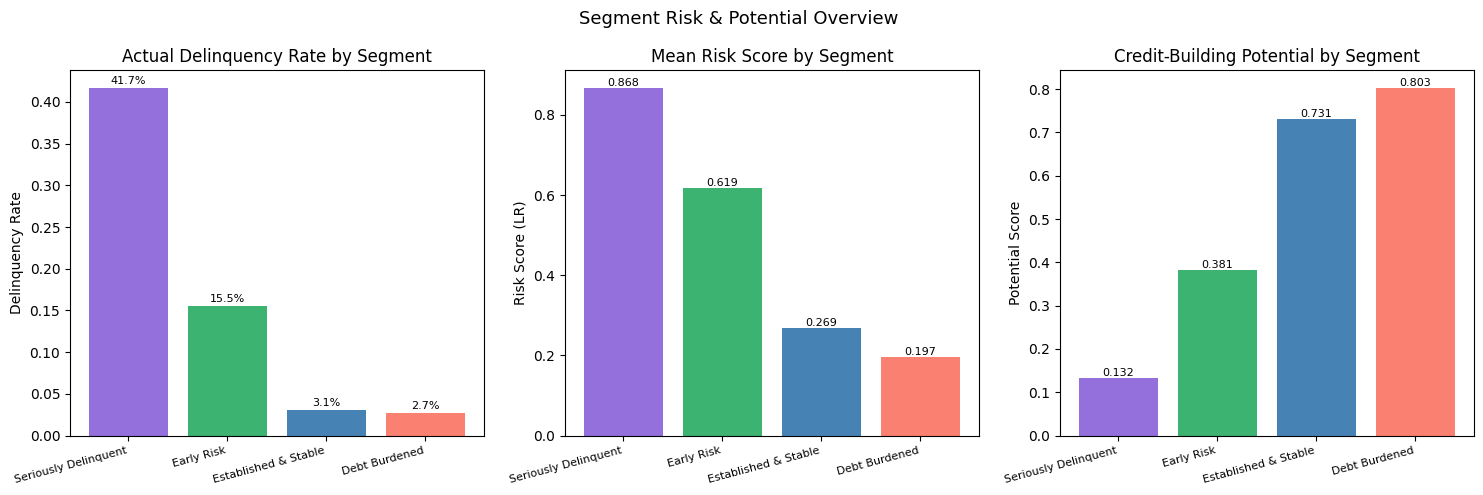

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

segment_order = ['Seriously Delinquent', 'Early Risk', 'Established & Stable', 'Debt Burdened']
colors = ['mediumpurple', 'mediumseagreen', 'steelblue', 'salmon']

# 1. Actual delinquency rate by segment
actual_rates = df.groupby('cluster_name')['SeriousDlqin2yrs'].mean().reindex(segment_order)
axes[0].bar(segment_order, actual_rates, color=colors, edgecolor='none')
axes[0].set_title('Actual Delinquency Rate by Segment')
axes[0].set_ylabel('Delinquency Rate')
axes[0].set_xticklabels(segment_order, rotation=15, ha='right', fontsize=8)
for i, v in enumerate(actual_rates):
    axes[0].text(i, v + 0.005, f'{v:.1%}', ha='center', fontsize=8)

# 2. Mean risk score by segment
risk_scores = df.groupby('cluster_name')['risk_score_lr'].mean().reindex(segment_order)
axes[1].bar(segment_order, risk_scores, color=colors, edgecolor='none')
axes[1].set_title('Mean Risk Score by Segment')
axes[1].set_ylabel('Risk Score (LR)')
axes[1].set_xticklabels(segment_order, rotation=15, ha='right', fontsize=8)
for i, v in enumerate(risk_scores):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=8)

# 3. Credit-building potential by segment
potential = df.groupby('cluster_name')['credit_building_potential'].mean().reindex(segment_order)
axes[2].bar(segment_order, potential, color=colors, edgecolor='none')
axes[2].set_title('Credit-Building Potential by Segment')
axes[2].set_ylabel('Potential Score')
axes[2].set_xticklabels(segment_order, rotation=15, ha='right', fontsize=8)
for i, v in enumerate(potential):
    axes[2].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=8)

plt.suptitle('Segment Risk & Potential Overview', fontsize=13)
plt.tight_layout()
plt.show()

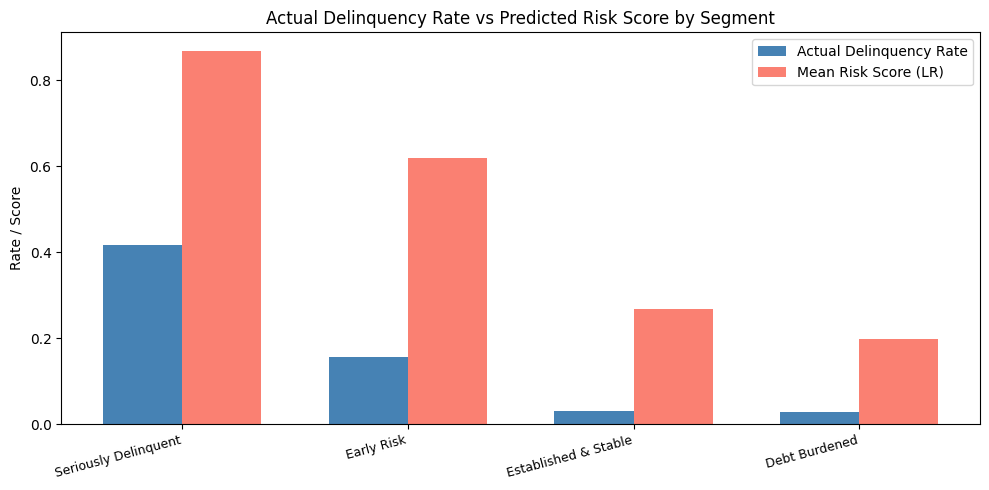

In [19]:
actual = df.groupby('cluster_name')['SeriousDlqin2yrs'].mean()
predicted = df.groupby('cluster_name')['risk_score_lr'].mean()

x = np.arange(len(actual))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, actual.reindex(segment_order), width,
       label='Actual Delinquency Rate', color='steelblue', edgecolor='none')
ax.bar(x + width/2, predicted.reindex(segment_order), width,
       label='Mean Risk Score (LR)', color='salmon', edgecolor='none')

ax.set_xticks(x)
ax.set_xticklabels(segment_order, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Rate / Score')
ax.set_title('Actual Delinquency Rate vs Predicted Risk Score by Segment')
ax.legend()
plt.tight_layout()
plt.show()

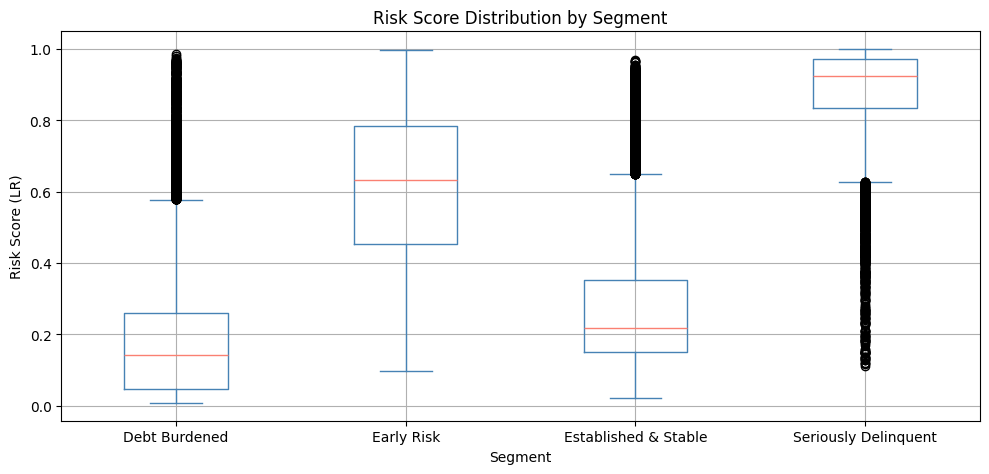

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
df.boxplot(column='risk_score_lr', by='cluster_name', ax=ax,
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='salmon'),
           whiskerprops=dict(color='steelblue'),
           capprops=dict(color='steelblue'))
ax.set_title('Risk Score Distribution by Segment')
ax.set_xlabel('Segment')
ax.set_ylabel('Risk Score (LR)')
plt.suptitle('')
plt.tight_layout()
plt.show()

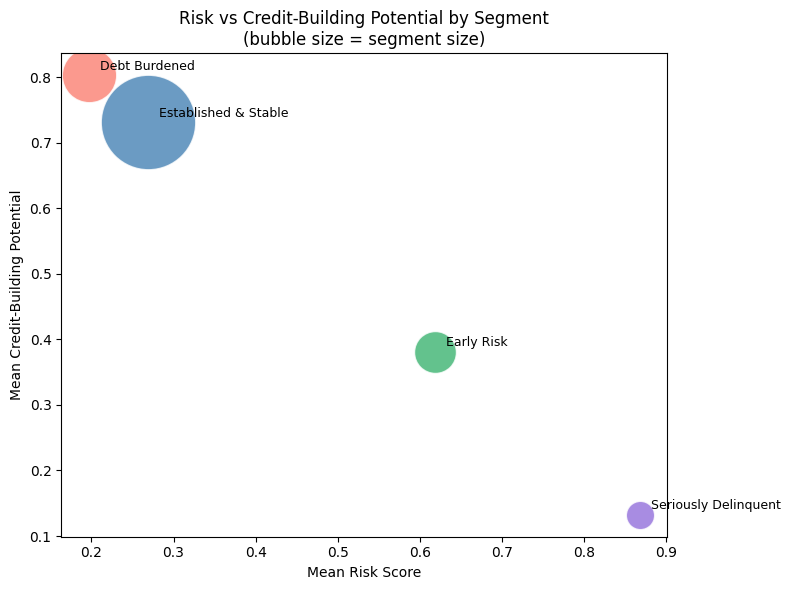

In [18]:
segment_summary = df.groupby('cluster_name').agg(
    risk=('risk_score_lr', 'mean'),
    potential=('credit_building_potential', 'mean'),
    size=('risk_score_lr', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(8, 6))
colors = {'Early Risk': 'mediumseagreen', 'Seriously Delinquent': 'mediumpurple',
          'Established & Stable': 'steelblue', 'Debt Burdened': 'salmon'}

for _, row in segment_summary.iterrows():
    ax.scatter(row['risk'], row['potential'],
               s=row['size']/20,
               color=colors[row['cluster_name']],
               alpha=0.8, edgecolors='white', linewidth=1)
    ax.annotate(row['cluster_name'],
                (row['risk'], row['potential']),
                textcoords='offset points', xytext=(8, 4), fontsize=9)

ax.set_xlabel('Mean Risk Score')
ax.set_ylabel('Mean Credit-Building Potential')
ax.set_title('Risk vs Credit-Building Potential by Segment\n(bubble size = segment size)')
plt.tight_layout()
plt.show()

### 1. Segment Risk & Potential Overview + Model Calibration
The three-panel chart confirms the segment hierarchy across all three dimensions. Seriously Delinquent is the clear outlier on risk (41.7% actual delinquency, 0.868 risk score), while Debt Burdened and Established & Stable cluster at the low-risk end despite very different financial profiles. Early Risk sits meaningfully above the low-risk segments — elevated but not severe — making it the most actionable segment for intervention.

The side-by-side actual vs predicted bars confirm the model is well-calibrated in relative terms — the directional ranking is correct across all segments (Seriously Delinquent > Early Risk > Established & Stable ≈ Debt Burdened). Predicted risk scores are consistently higher than observed delinquency rates, which is expected behavior with `class_weight='balanced'` — the model intentionally biases toward flagging risk to maximize recall on the minority class.

---

### 2. Risk Score Distribution by Segment (Box Plot)
The box plot reveals within-segment variation that mean scores alone obscure:

- **Seriously Delinquent** — tight, high distribution (IQR ~0.85–0.95) with some outliers below 0.6. The most homogeneous high-risk group — almost all borrowers in this segment are genuinely high risk
- **Early Risk** — wide IQR (~0.45–0.78), indicating meaningful internal variation. Some borrowers in this segment may be closer to Established & Stable than the mean suggests — opportunity for further sub-segmentation in production
- **Established & Stable** — low median (~0.22) but a long upper tail of outliers reaching near 1.0 — a small proportion of this segment carries hidden risk
- **Debt Burdened** — low median (~0.15) with a long upper whisker, consistent with the structural rather than behavioral nature of their risk

---

### 3. Risk vs Credit-Building Potential Scatter
The bubble chart (sized by segment) illustrates the core tension of the analysis. Debt Burdened and Established & Stable sit in the low-risk, high-potential quadrant — but neither is the right target. Debt Burdened has a structural debt problem that credit products cannot solve, and Established & Stable is already financially healthy. Early Risk sits alone in the moderate-risk, moderate-potential space — the only segment where intervention is both needed and likely to succeed. Seriously Delinquent is isolated in the high-risk, low-potential corner.

## 6. Product recommendation matrix

In [21]:
product_matrix = pd.DataFrame({
    'Segment': ['Early Risk', 'Debt Burdened', 'Established & Stable', 'Seriously Delinquent'],
    'Risk Level': ['Moderate', 'Low', 'Low', 'High'],
    'Credit-Building Potential': ['Moderate', 'High*', 'High*', 'Low'],
    'Recommended Product': [
        'Credit builder line + financial education',
        'Budgeting and/or debt management tools',
        'Not a primary target',
        'Debt counseling before any credit product'
    ],
    'Suggested Credit Limit Tier': [
        'Low ($300–$500)',
        'None — address debt obligations first',
        'N/A',
        'None'
    ],
    'Expected Outcome': [
        'Score improvement within 6–12 months with on-time payments',
        'Reduced debt burden, potential credit product in phase 2',
        'Already credit healthy',
        'Stabilization before credit building'
    ]
})

print(product_matrix.to_string(index=False))

             Segment Risk Level Credit-Building Potential                       Recommended Product           Suggested Credit Limit Tier                                           Expected Outcome
          Early Risk   Moderate                  Moderate Credit builder line + financial education                       Low ($300–$500) Score improvement within 6–12 months with on-time payments
       Debt Burdened        Low                     High*    Budgeting and/or debt management tools None — address debt obligations first   Reduced debt burden, potential credit product in phase 2
Established & Stable        Low                     High*                      Not a primary target                                   N/A                                     Already credit healthy
Seriously Delinquent       High                       Low Debt counseling before any credit product                                  None                       Stabilization before credit building


*High potential score reflects low delinquency risk, not product readiness. Debt Burdened borrowers carry structural debt obligations exceeding income — a credit product would add to their burden rather than relieve it. Potential score should be interpreted alongside segment context, not in isolation.

## 7. Stakeholder narrative

### Who Should We Target First?

This analysis set out to answer a simple question: among 150,000 borrowers, who is most likely to successfully build credit if given the right product? The answer is not the borrowers with the highest credit-building potential score — it is the borrowers where potential, need, and product fit intersect.

The **Early Risk segment (18,242 borrowers, 12.2% of the dataset)** is the primary target. These borrowers have good income, moderate credit utilization, and have shown early signs of financial stress — 100% have been 30 days late at least once, but almost none have escalated to 60 or 90-day delinquency. This is the intervention window. A structured credit-building product with a low initial limit ($300–$500), automatic payment reminders, and integrated financial education could help these borrowers course-correct before stress compounds. With on-time payments, meaningful credit score improvement is achievable within 6–12 months.

The **Debt Burdened segment (30,741 borrowers, 20.5%)** is the most counterintuitive finding. Their delinquency risk is low (2.7% actual rate) and their credit-building potential score is the highest of any group — yet they are not a good target for a credit product. Nearly 100% carry debt obligations exceeding their monthly income, meaning additional credit would add to their burden rather than relieve it. The right intervention is financial coaching or debt management tools first, with credit products as a phase 2 offering once obligations are brought under control.

The **Seriously Delinquent segment (8,324 borrowers, 5.5%)** is the highest-risk group by every measure — 41.7% actual delinquency rate, 0.868 mean risk score, 100% with prior 90-day late payments. Offering credit here without addressing underlying behavior would likely accelerate financial deterioration. Debt counseling and financial stabilization are prerequisites before any credit product is appropriate.

The **Established & Stable segment (92,693 borrowers, 61.8%)** is the financially healthy majority — low risk, clean delinquency history, older and more financially mature. They are not the target market for a credit-building product but serve as a useful benchmark: the goal of any intervention in the other segments is to move borrowers toward this profile over time.

## 8. Save final output

In [22]:
df.to_csv('data/final.csv', index=False)